# Stiffness and force tracking — force+position control

Closed-loop force+position control: gradient descent on K_d (model-based) vs scalar k·I baseline.
Feedback from load cell; reference is a staircase through force levels.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os, sys
from glob import glob
from scipy.signal import savgol_filter

sys.path.insert(0, os.path.join('../'))
from plot_config import draw_radar, COLORS, FIG_W_SINGLE, FIG_W_DOUBLE, set_font_size
FIG_W = 10   # inches — change freely

FIG_H = 6    # inches — change freely

GRID = False
FONT_SIZE = 18  # pt — change to rescale all text uniformly
set_font_size(FONT_SIZE)

from StiffnessForceTracking.experiment_config import FORCE_LEVELS, STEP_HOLD, TRACK_DURATION

OUTPUT_DIR_MODEL  = os.path.join('outputs', 'force_position_control')
OUTPUT_DIR_SCALAR = os.path.join('outputs', 'force_position_control_scalar')
plt.rcParams['savefig.bbox'] = 'tight'
COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']

def load_runs(output_dir, prefix):
    files = sorted(glob(os.path.join(output_dir, f'{prefix}_*.csv')))
    return [pd.read_csv(f) for f in files]

def interp_time(dfs, col='Force_Normal_N', n_pts=600):
    """Interpolate runs onto a common time grid."""
    t_max = min(df['Time_s'].max() for df in dfs)
    t = np.linspace(0, t_max, n_pts)
    vals = np.array([np.interp(t, df['Time_s'], df[col]) for df in dfs])
    return t, vals

def smooth(x, window=21, poly=3):
    """Savitzky-Golay smoothing; falls back to raw signal if too short."""
    if len(x) < window:
        return x
    return savgol_filter(x, window_length=window, polyorder=poly)

def darken(color, factor=0.6):
    r, g, b = mcolors.to_rgb(color)
    return r * factor, g * factor, b * factor

def tracking_rmse(force, force_ref):
    return float(np.sqrt(np.mean((force - force_ref) ** 2)))

def approximate_transition_time(t, force, force_ref, low=0.1, high=0.9, eps=1e-6, mode='both'):
    if mode == 'rise':
        step_idx = np.where(np.diff(force_ref) > eps)[0]
    elif mode == 'fall':
        step_idx = np.where(np.diff(force_ref) < -eps)[0]
    else:
        step_idx = np.where(np.abs(np.diff(force_ref)) > eps)[0]
    transition_times = []
    for j, i in enumerate(step_idx):
        y0 = force_ref[i]
        y1 = force_ref[i + 1]
        amp = y1 - y0
        if np.abs(amp) <= eps:
            continue
        seg_start = i + 1
        seg_end = step_idx[j + 1] if j + 1 < len(step_idx) else len(t) - 1
        t_seg = t[seg_start:seg_end + 1]
        y_seg = force[seg_start:seg_end + 1]
        if len(t_seg) == 0:
            continue
        if amp > 0:
            y_low = y0 + low * amp
            y_high = y0 + high * amp
            idx_low = np.where(y_seg >= y_low)[0]
            idx_high = np.where(y_seg >= y_high)[0]
        else:
            y_low = y0 + low * amp
            y_high = y0 + high * amp
            idx_low = np.where(y_seg <= y_low)[0]
            idx_high = np.where(y_seg <= y_high)[0]
        if len(idx_low) == 0 or len(idx_high) == 0:
            continue
        t_low = t_seg[idx_low[0]]
        t_high = t_seg[idx_high[0]]
        if t_high >= t_low:
            transition_times.append(t_high - t_low)
    if not transition_times:
        return np.nan, 0
    return float(np.mean(transition_times)), len(transition_times)

def approximate_rise_time(t, force, force_ref, low=0.1, high=0.9, eps=1e-6):
    return approximate_transition_time(t, force, force_ref, low=low, high=high, eps=eps, mode='rise')

def approximate_fall_time(t, force, force_ref, low=0.1, high=0.9, eps=1e-6):
    return approximate_transition_time(t, force, force_ref, low=low, high=high, eps=eps, mode='fall')

def approximate_risefall_time(t, force, force_ref, low=0.1, high=0.9, eps=1e-6):
    return approximate_transition_time(t, force, force_ref, low=low, high=high, eps=eps, mode='both')

runs_model = load_runs(OUTPUT_DIR_MODEL, 'force_position_control')
runs_scalar = load_runs(OUTPUT_DIR_SCALAR, 'force_position_control_scalar')
print(f'Model:  {len(runs_model)} run(s)')
print(f'Scalar: {len(runs_scalar)} run(s)')

Model:  5 run(s)
Scalar: 5 run(s)


In [2]:
if not runs_model:
    raise FileNotFoundError(f'No CSV found in {OUTPUT_DIR_MODEL}')

if not runs_scalar:
    print(f'No CSV found in {OUTPUT_DIR_SCALAR}; scalar plot will be skipped.')

## Force tracking — model-based vs scalar

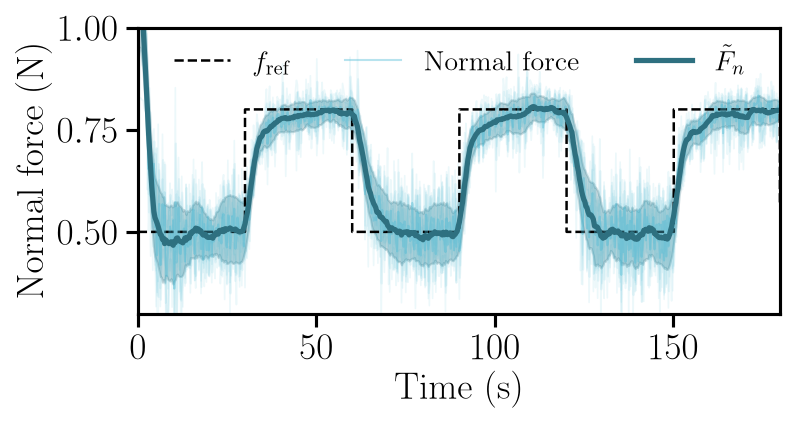

In [3]:
# ---- size / aspect for THIS graph only ----
W_IN   = 8.5 * 0.65
ASPECT = 5.15 / 9
H_IN   = W_IN * ASPECT
fig, ax = plt.subplots(figsize=(W_IN, H_IN))

t_ref, ref_vals = interp_time(runs_model, col='Force_Ref_N')
t, vals = interp_time(runs_model, col='Force_Normal_N')
mean, std = vals.mean(0), vals.std(0)
ref_mean = ref_vals.mean(0)

mean_s = smooth(mean)
std_s  = smooth(std)
dark = darken(COLORS[0])

for v in vals:
    ax.plot(t, v, color=COLORS[0], alpha=0.10, linewidth=0.8)
ax.step(t_ref, ref_mean, color='black', linewidth=1.2,
        linestyle='--', where='post', label=r'$f_{\mathrm{ref}}$')
ax.fill_between(t, mean - std, mean + std, color=COLORS[0], alpha=0.10)
ax.plot(t, mean, color=COLORS[0], linewidth=1.0, alpha=0.40,
        label='Normal force')
ax.plot(t, mean_s, color=dark, linewidth=2.5,
        label=r'$\tilde{F}_n$')
ax.fill_between(t, mean_s - std_s, mean_s + std_s, color=dark, alpha=0.25)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Normal force (N)')
ax.legend(loc='best', ncol=3)
ax.set_xlim(0, TRACK_DURATION)
ax.set_ylim(0.3, 1.0)
rmse_model = tracking_rmse(mean, ref_mean)

plt.tight_layout()
os.makedirs(OUTPUT_DIR_MODEL, exist_ok=True)
fig.savefig(os.path.join(OUTPUT_DIR_MODEL, 'force_tracking_model.pdf'))
plt.show()

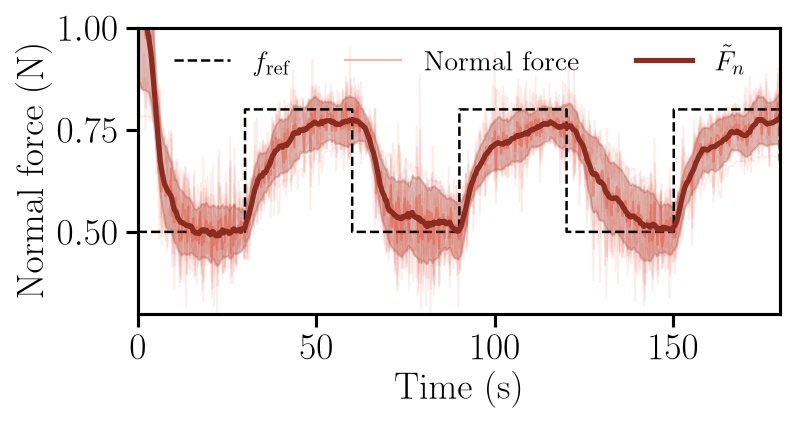

In [4]:
if not runs_scalar:
    print('Skipping scalar plot: no scalar CSV files found.')
else:
    # ---- size / aspect for THIS graph only ----
    W_IN   = 8.5 * 0.65
    ASPECT = 5.15 / 9
    H_IN   = W_IN * ASPECT
    fig, ax = plt.subplots(figsize=(W_IN, H_IN))

    t_ref, ref_vals = interp_time(runs_scalar, col='Force_Ref_N')
    t, vals = interp_time(runs_scalar, col='Force_Normal_N')
    mean, std = vals.mean(0), vals.std(0)
    ref_mean = ref_vals.mean(0)

    mean_s = smooth(mean)
    std_s  = smooth(std)
    dark = darken(COLORS[1])

    for v in vals:
        ax.plot(t, v, color=COLORS[1], alpha=0.10, linewidth=0.8)
    ax.step(t_ref, ref_mean, color='black', linewidth=1.2,
            linestyle='--', where='post', label=r'$f_{\mathrm{ref}}$')
    ax.fill_between(t, mean - std, mean + std, color=COLORS[1], alpha=0.10)
    ax.plot(t, mean, color=COLORS[1], linewidth=1.0, alpha=0.40,
            label='Normal force')
    ax.plot(t, mean_s, color=dark, linewidth=2.5,
            label=r'$\tilde{F}_n$')
    ax.fill_between(t, mean_s - std_s, mean_s + std_s, color=dark, alpha=0.25)

    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Normal force (N)')
    ax.legend(loc='best', ncol=3)
    ax.set_xlim(0, TRACK_DURATION)
    ax.set_ylim(0.3, 1.0)
    rmse_scalar = tracking_rmse(mean, ref_mean)

    plt.tight_layout()
    os.makedirs(OUTPUT_DIR_MODEL, exist_ok=True)
    fig.savefig(os.path.join(OUTPUT_DIR_MODEL, 'force_tracking_scalar.pdf'))
    plt.show()

## Controller quality metrics

In [5]:
t_model, ref_model_vals = interp_time(runs_model, col='Force_Ref_N')
_, force_model_vals = interp_time(runs_model, col='Force_Normal_N')
ref_model = ref_model_vals.mean(0)
force_model = smooth(force_model_vals.mean(0))

rmse_model = tracking_rmse(force_model, ref_model)
rise_model, n_rise_model = approximate_rise_time(t_model, force_model, ref_model)
fall_model, n_fall_model = approximate_fall_time(t_model, force_model, ref_model)
rf_model, n_rf_model = approximate_risefall_time(t_model, force_model, ref_model)

print('Model controller metrics:')
print(f'  RMSE: {rmse_model:.4f} N')
if np.isfinite(rise_model):
    print(f'  Approx. rise time (10-90%): {rise_model:.3f} s over {n_rise_model} step(s)')
else:
    print('  Approx. rise time (10-90%): not available')
if np.isfinite(fall_model):
    print(f'  Approx. fall time (90-10%): {fall_model:.3f} s over {n_fall_model} step(s)')
else:
    print('  Approx. fall time (90-10%): not available')
if np.isfinite(rf_model):
    print(f'  Approx. transition (response) time, rise/fall (10-90%): {rf_model:.3f} s over {n_rf_model} step(s)')
else:
    print('  Approx. transition (response) time, rise/fall (10-90%): not available')

if runs_scalar:
    t_scalar, ref_scalar_vals = interp_time(runs_scalar, col='Force_Ref_N')
    _, force_scalar_vals = interp_time(runs_scalar, col='Force_Normal_N')
    ref_scalar = ref_scalar_vals.mean(0)
    force_scalar = smooth(force_scalar_vals.mean(0))

    rmse_scalar = tracking_rmse(force_scalar, ref_scalar)
    rise_scalar, n_rise_scalar = approximate_rise_time(t_scalar, force_scalar, ref_scalar)
    fall_scalar, n_fall_scalar = approximate_fall_time(t_scalar, force_scalar, ref_scalar)
    rf_scalar, n_rf_scalar = approximate_risefall_time(t_scalar, force_scalar, ref_scalar)

    print('Scalar controller metrics:')
    print(f'  RMSE: {rmse_scalar:.4f} N')
    if np.isfinite(rise_scalar):
        print(f'  Approx. rise time (10-90%): {rise_scalar:.3f} s over {n_rise_scalar} step(s)')
    else:
        print('  Approx. rise time (10-90%): not available')
    if np.isfinite(fall_scalar):
        print(f'  Approx. fall time (90-10%): {fall_scalar:.3f} s over {n_fall_scalar} step(s)')
    else:
        print('  Approx. fall time (90-10%): not available')
    if np.isfinite(rf_scalar):
        print(f'  Approx. transition (response) time, rise/fall (10-90%): {rf_scalar:.3f} s over {n_rf_scalar} step(s)')
    else:
        print('  Approx. transition (response) time, rise/fall (10-90%): not available')

    rel_gain = 100.0 * (rmse_scalar - rmse_model) / rmse_scalar if rmse_scalar > 0 else 0.0
    print(f'RMSE improvement (model vs scalar): {rel_gain:.2f}%')
    if np.isfinite(rise_model) and np.isfinite(rise_scalar) and rise_scalar > 0:
        rise_gain = 100.0 * (rise_scalar - rise_model) / rise_scalar
        print(f'Rise-time speed-up (model vs scalar): {rise_gain:.2f}%')
    if np.isfinite(fall_model) and np.isfinite(fall_scalar) and fall_scalar > 0:
        fall_gain = 100.0 * (fall_scalar - fall_model) / fall_scalar
        print(f'Fall-time speed-up (model vs scalar): {fall_gain:.2f}%')
    if np.isfinite(rf_model) and np.isfinite(rf_scalar) and rf_scalar > 0:
        rf_gain = 100.0 * (rf_scalar - rf_model) / rf_scalar
        print(f'Transition-time speed-up (model vs scalar): {rf_gain:.2f}%')
else:
    print('Scalar controller metrics unavailable (no scalar run data).')

Model controller metrics:
  RMSE: 0.0982 N
  Approx. rise time (10-90%): 9.616 s over 3 step(s)
  Approx. fall time (90-10%): 7.513 s over 2 step(s)
  Approx. transition (response) time, rise/fall (10-90%): 8.775 s over 5 step(s)
Scalar controller metrics:
  RMSE: 0.1379 N
  Approx. rise time (10-90%): 21.336 s over 2 step(s)
  Approx. fall time (90-10%): 18.932 s over 2 step(s)
  Approx. transition (response) time, rise/fall (10-90%): 20.134 s over 4 step(s)
RMSE improvement (model vs scalar): 28.75%
Rise-time speed-up (model vs scalar): 54.93%
Fall-time speed-up (model vs scalar): 60.32%
Transition-time speed-up (model vs scalar): 56.42%
